In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import gseapy as gp
import os
import pickle
import importlib
from scipy.stats import chisquare

import subcluster_funcs as funcs

importlib.reload(funcs)
sc._settings.settings._vector_friendly=True

import matplotlib
from statsmodels.stats.multitest import multipletests

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
post_subclustering_dir = "../post_subcluster_annotation/"
os.makedirs(post_subclustering_dir, exist_ok=True)
plots_dir = "plots_dir/"
os.makedirs(plots_dir, exist_ok=True)

In [3]:
cell_type = "Adipocyte"

In [4]:
adata = sc.read_h5ad("../continuous_cov_corrected_no_scvi/" + cell_type  + ".h5ad")

<module 'matplotlib.pyplot' from '/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/matplotlib/pyplot.py'>

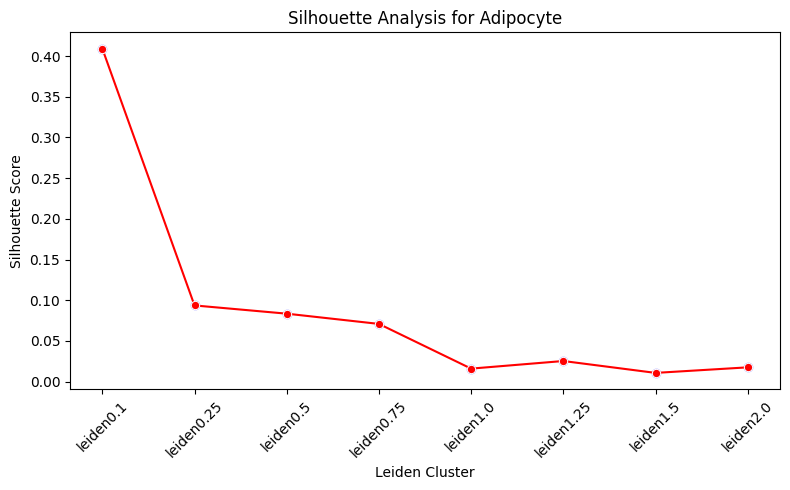

In [5]:
funcs.silhouette(adata, silhouette_res_dir = "../silhouette_res_scVI/", cell_type = cell_type)

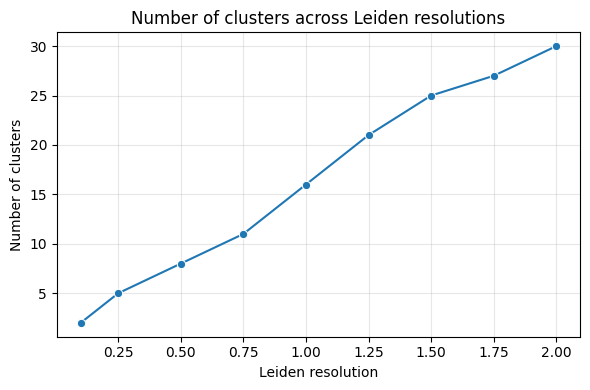

In [6]:
cluster_df, fig = funcs.leiden_resolution_summary(adata)

### Use Leiden 0.25 

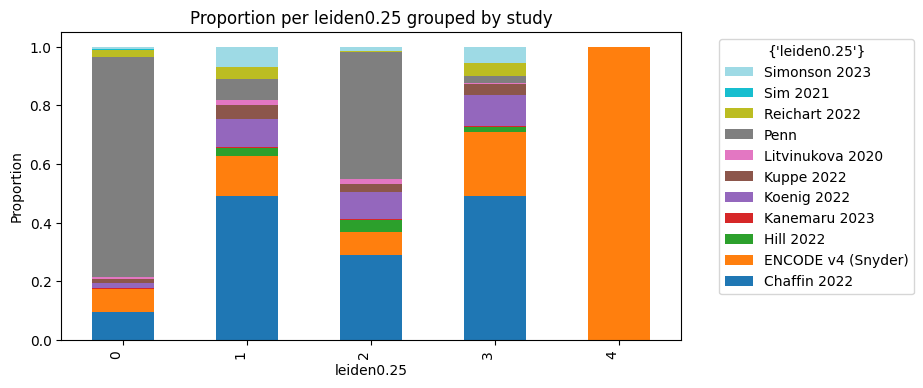

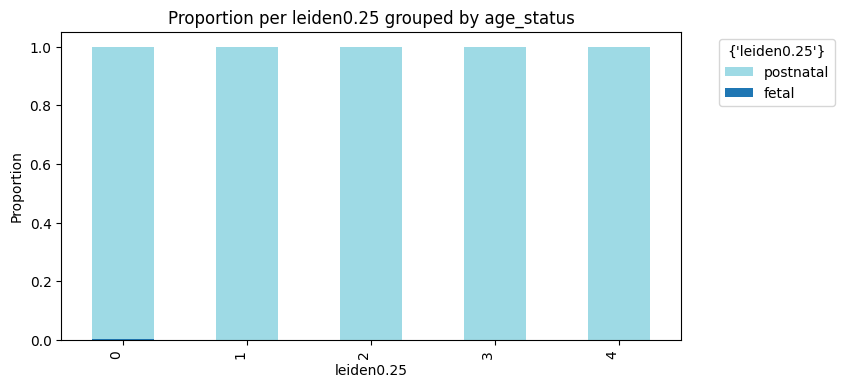

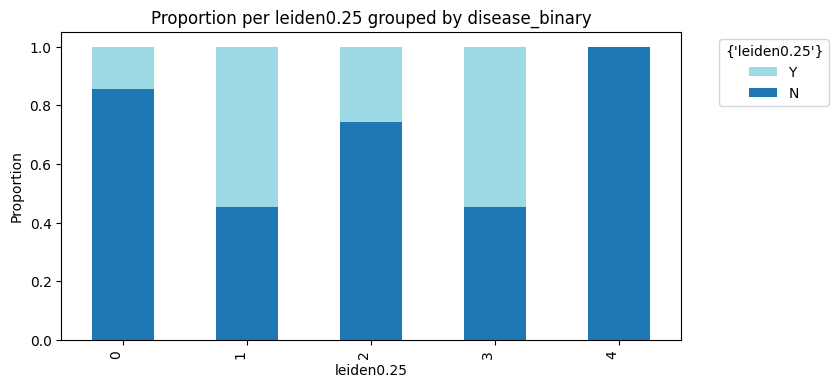

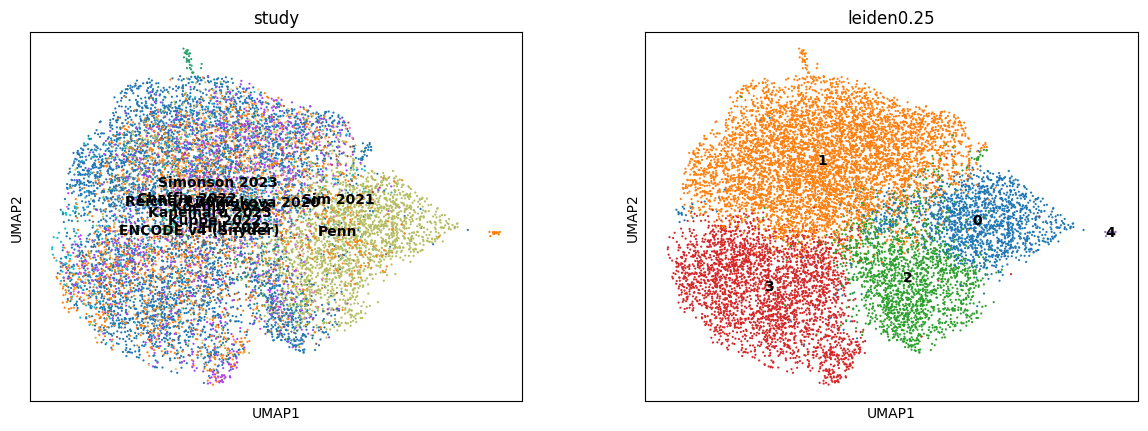

/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean

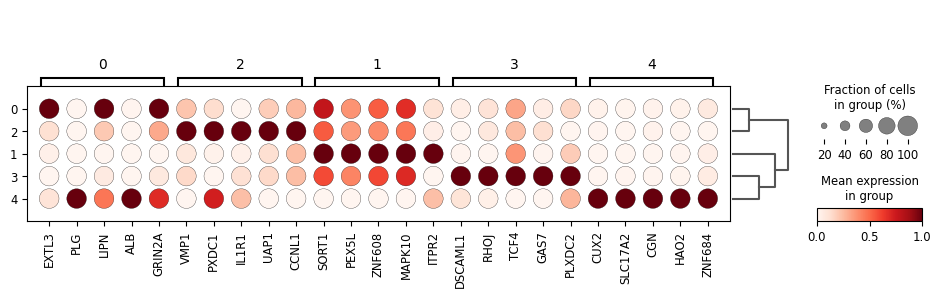

Counter({'1': 5751, '3': 2932, '2': 1797, '0': 1602, '4': 16})


['leiden0.25',
 AnnData object with n_obs × n_vars = 12098 × 16115
     obs: 'age', 'donor_id', 'sex', 'region', 'cell_type', 'disease', 'consistent_cell_type', 'study', 'technology', 'cell_or_nuclei', 'barcode', 'sample_id', 'age_status', 'tech_plus_study', 'disease_binary', 'decade', 'age_group', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'scvi_cell_type', 'redo_leiden_0.5', 'UMAP1', 'UMAP2', 'v2_scvi_cell_type', 'final_cell_type', 'total_UMI', 'log10_UMI', 'endo_score', 'cm_score', 'fib_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'l

In [7]:
leiden_key = "leiden0.25"
funcs.specify_leiden_subclustering(adata=adata, leiden=leiden_key)

In [8]:
adata.obs['age_disease'] = adata.obs['age_status'].astype(str) + ":" + adata.obs['disease'].astype(str)

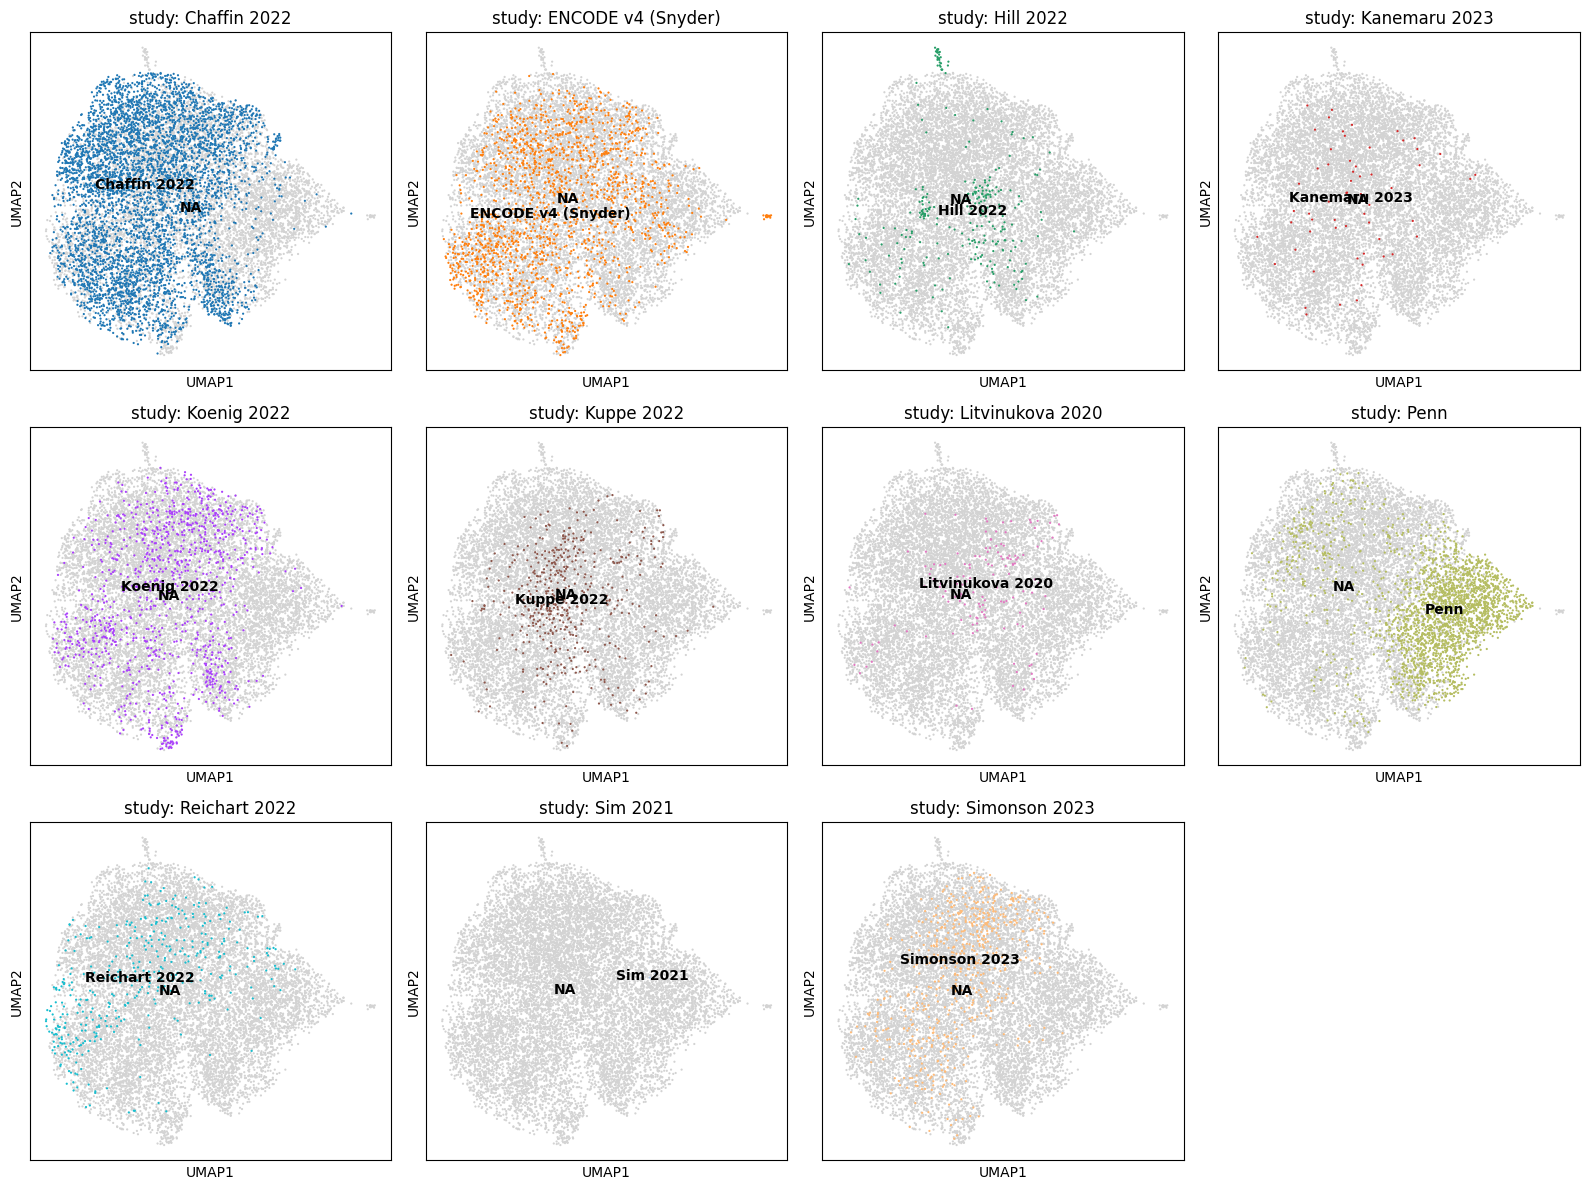

In [9]:
funcs.plot_umap_by_cluster(adata, metadata_key = "study")

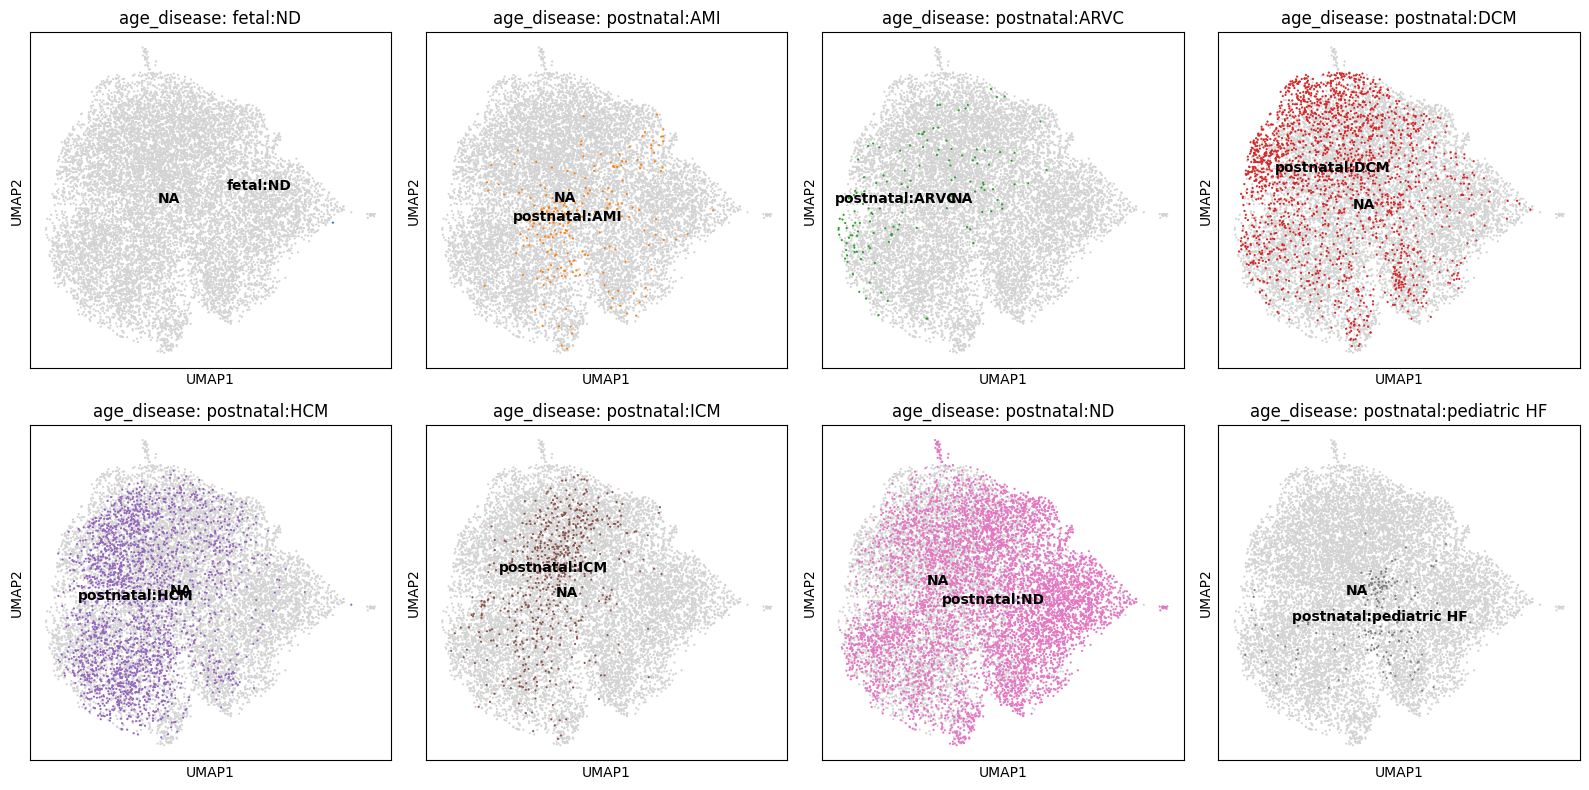

In [10]:
funcs.plot_umap_by_cluster(adata, metadata_key = "age_disease")

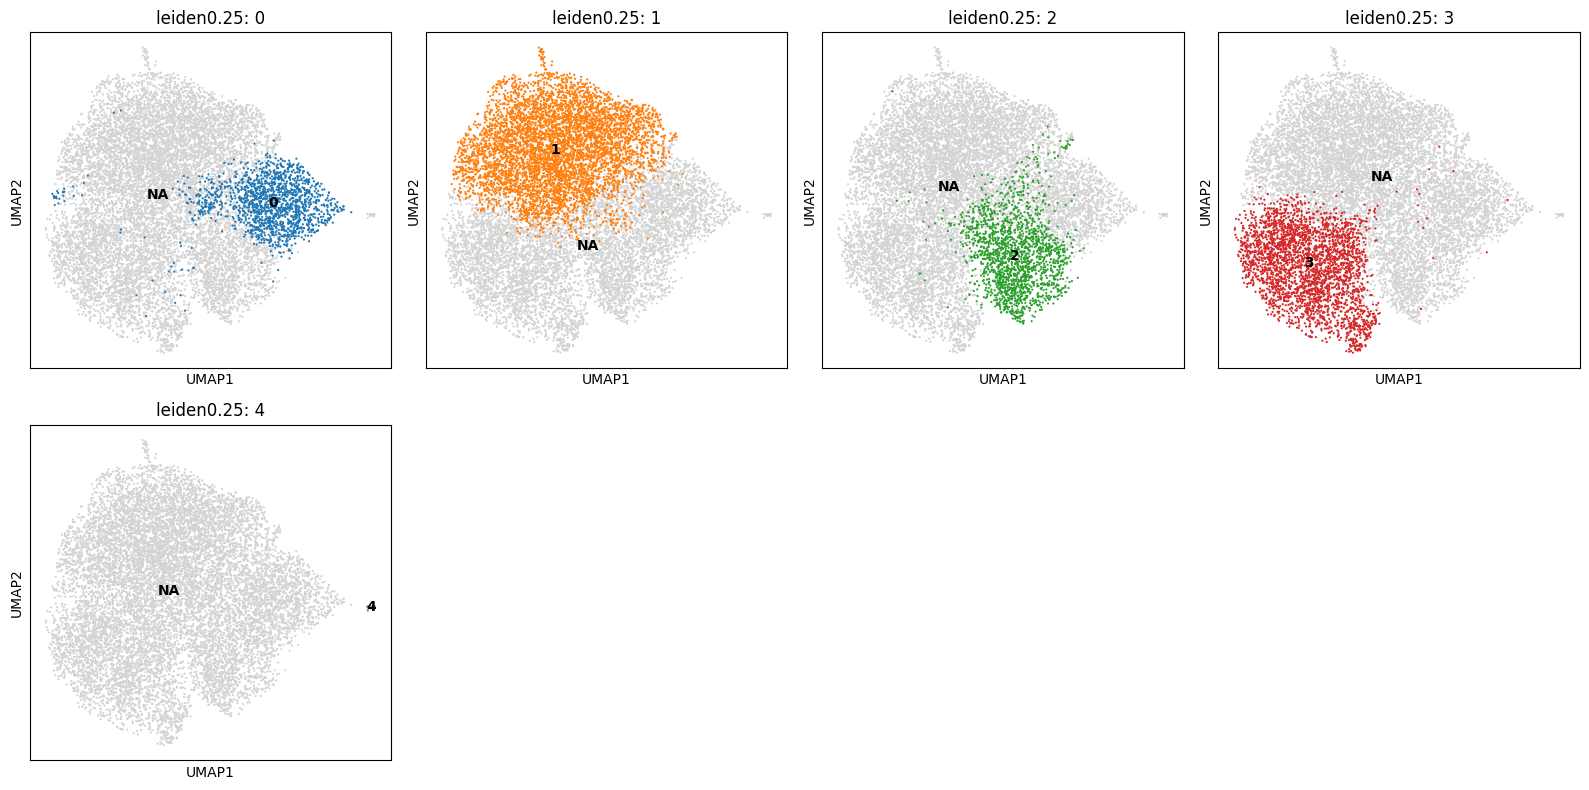

In [11]:
funcs.plot_umap_by_cluster(adata, metadata_key = leiden_key)

### Marker gene / ORA analysis

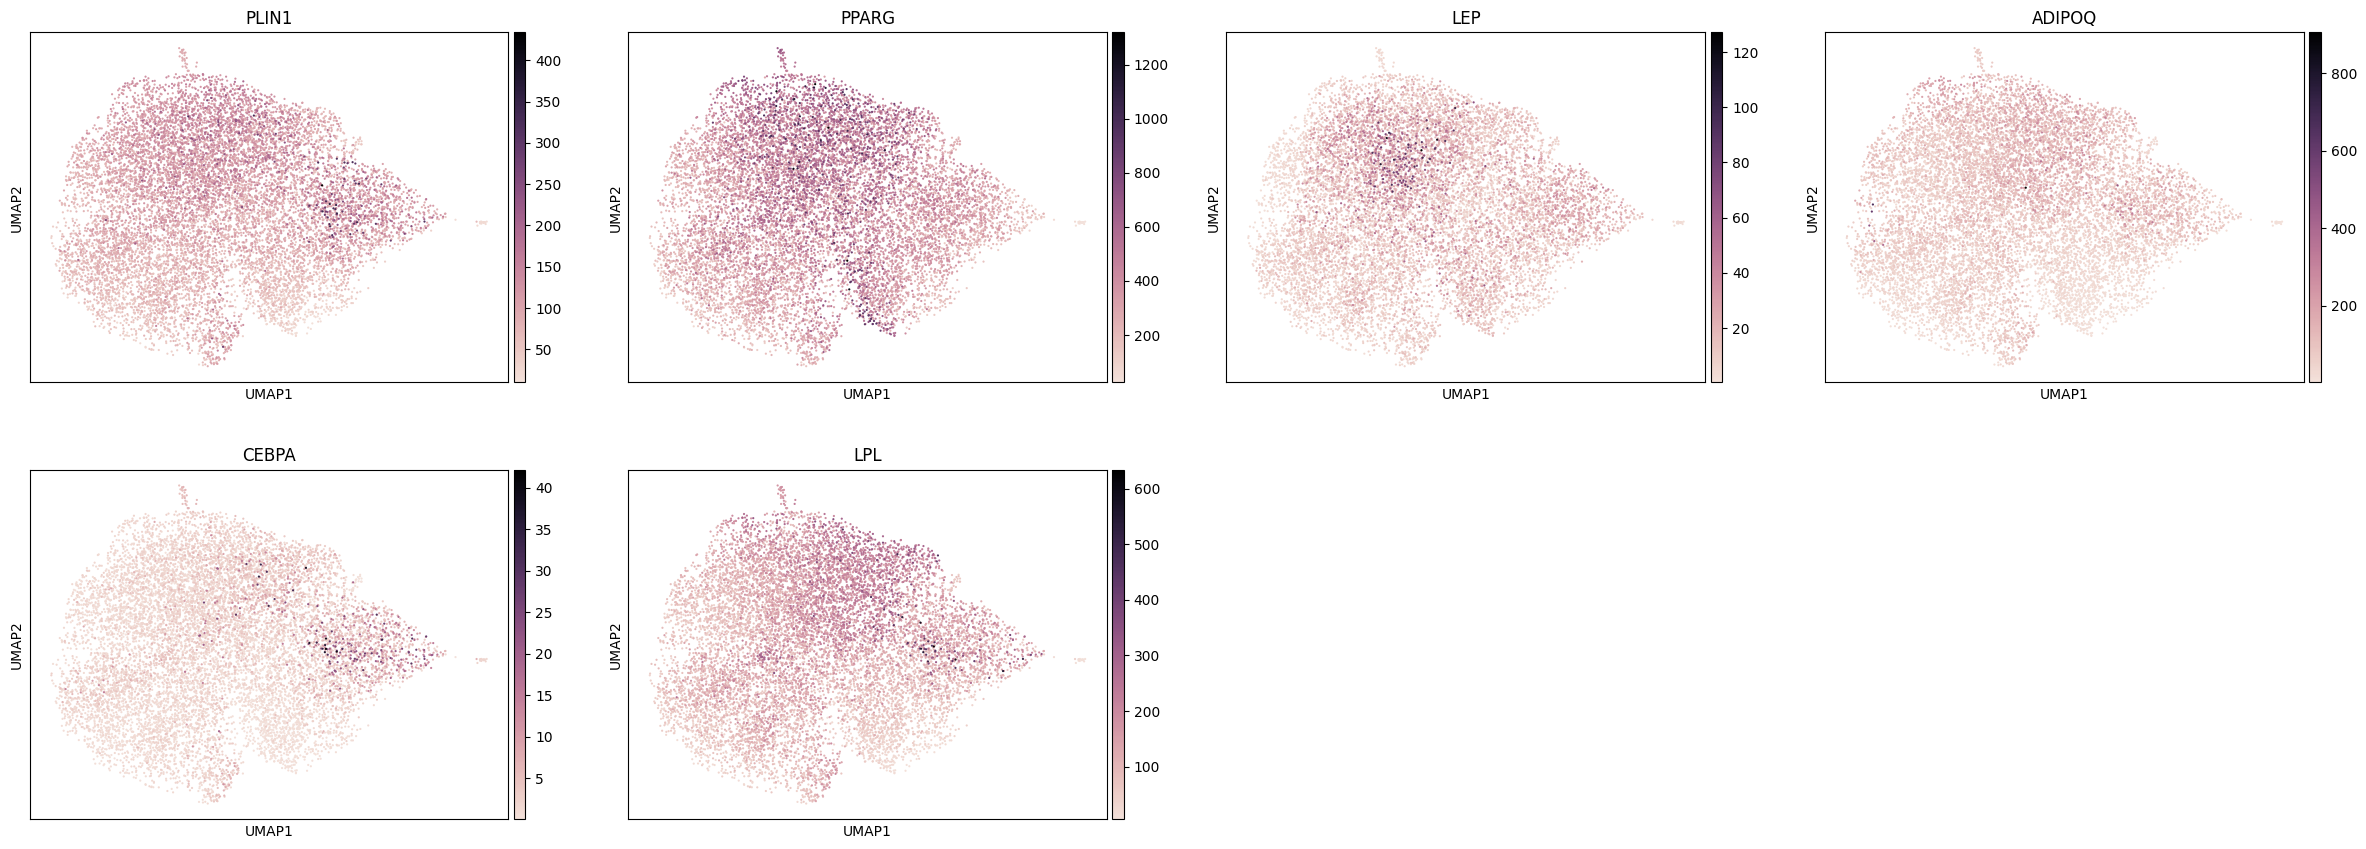

In [12]:
# white adipocyte markers
sc.pl.umap(adata, color = ["PLIN1", "PPARG", "LEP", 
                           "ADIPOQ", "CEBPA", "LPL"], 
           cmap=sns.cubehelix_palette(dark=0, light=.9, as_cmap=True))

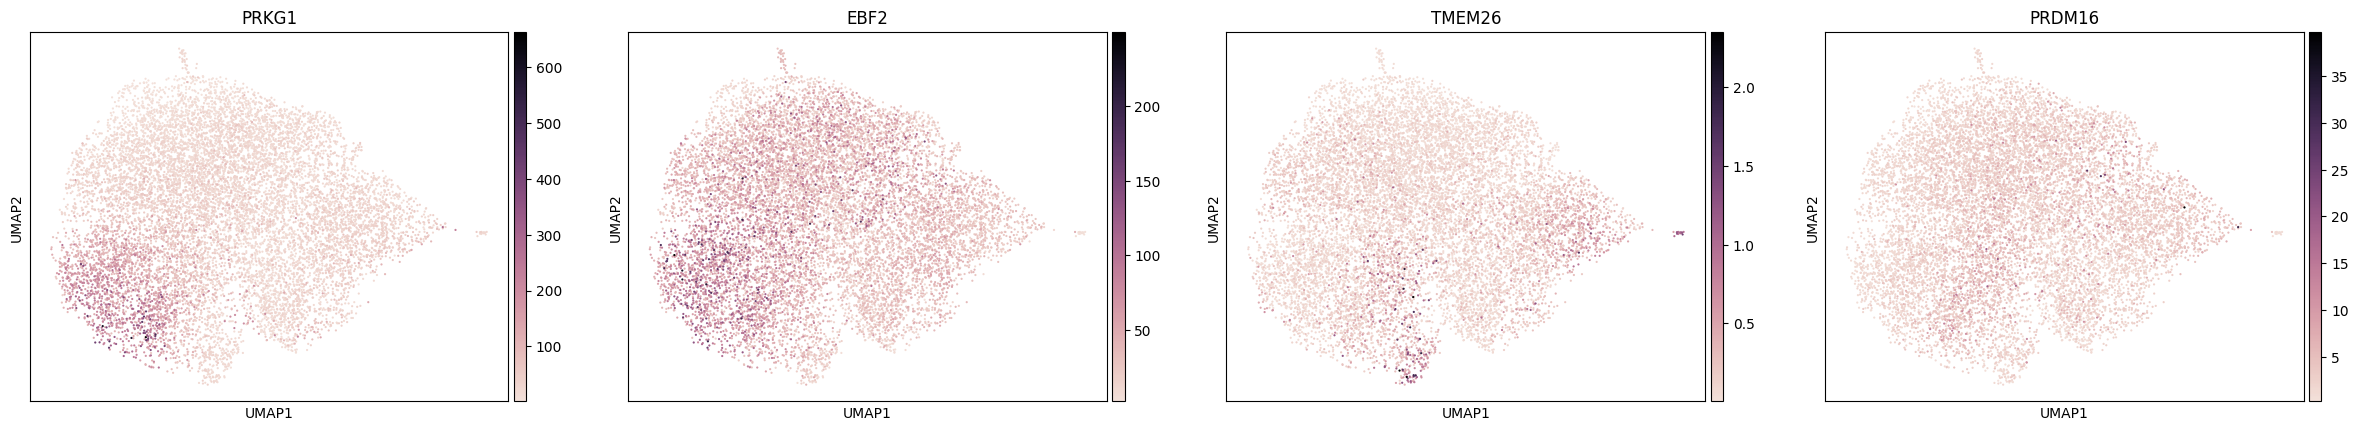

In [31]:
# beige adipocyte markers
sc.pl.umap(adata, color = ["PRKG1", "EBF2", "TMEM26", 
                           "PRDM16"], cmap=sns.cubehelix_palette(dark=0, light=.9, as_cmap=True))

In [14]:
#sc.pl.umap(adata, color = leiden_key, legend_loc = "on data")

In [32]:
#sc.get.rank_genes_groups_df(adata, group="3")['names'].head(40)

### Subcluster annotation

- Cluster 0-2, 4 are enriched from white adipocytes (ADIPOQ, LPL, CEPBA)
- Clusters 3 are beige adipocytes (TMEM26, EBF2, CD34, PRKG1, KCNT2)

In [44]:
adata.obs['subcluster'] = adata.obs['leiden0.25'].map(
    {"0": "White",
     "1": "White",
     "2": "White",
     "3": "Beige",
     "4": "White", 
    }
)

subcluster_order = ["Beige", "White"]

# define colors for each subcluster
subcluster_colors = {
    "White": "gray",      
    "Beige": "tan", 
}

adata.obs['subcluster'] = pd.Categorical(adata.obs['subcluster'], categories=subcluster_order, ordered=True)

### Produce plots

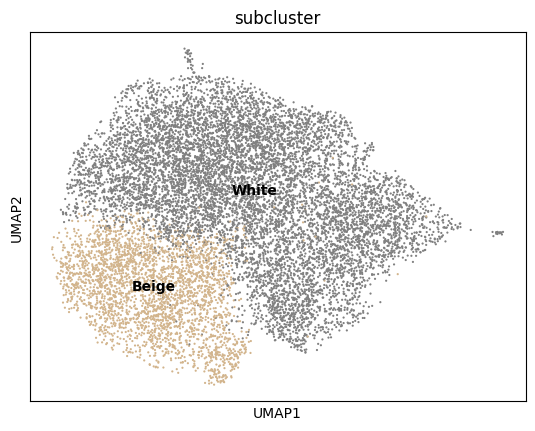

In [45]:
with plt.rc_context(): 
    sc.pl.umap(adata, color = ['subcluster'], legend_loc = "on data", palette=subcluster_colors, show=False)
    plt.savefig(plots_dir + cell_type + "_subclustered.pdf", bbox_inches="tight")

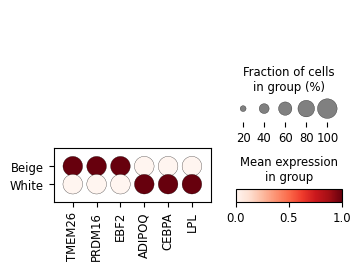

In [47]:
with plt.rc_context(): 
    sc.pl.dotplot(adata, var_names = ["TMEM26", "PRDM16", "EBF2",
                                      "ADIPOQ", "CEBPA", "LPL"], groupby = "subcluster", show=False, standard_scale='var')
    plt.savefig(plots_dir + cell_type + "_subclustered_dotplot.pdf", bbox_inches="tight")

In [36]:
subcluster_stats = (
    adata.obs['subcluster']
    .value_counts(normalize=False)
    .rename("count")
    .reset_index()
    .rename(columns={"index": "subcluster"})
)

subcluster_stats["proportion"] = subcluster_stats["count"] / subcluster_stats["count"].sum()

print(subcluster_stats)

  subcluster  count  proportion
0      White   9166    0.757646
1      Beige   2932    0.242354


### Show enrichments by disease-age status and age group

In [37]:
adata_metadata = adata.obs

disease_filtered_metadata = adata_metadata[~adata_metadata['age_disease'].isin(["postnatal:ARVC", "postnatal:NCCM"])].copy()
for col in disease_filtered_metadata.select_dtypes('category').columns:
    disease_filtered_metadata[col] = disease_filtered_metadata[col].cat.remove_unused_categories()
    
ND_adata_metadata = adata_metadata[adata_metadata['disease_binary'] == "N"].copy()

In [38]:
Counter(disease_filtered_metadata.age_disease)

Counter({'postnatal:ND': 6649,
         'postnatal:HCM': 2259,
         'postnatal:DCM': 2029,
         'postnatal:ICM': 615,
         'postnatal:AMI': 225,
         'postnatal:pediatric HF': 176,
         'fetal:ND': 3})

/mnt/data1/william/human_heart_project/Final_manuscript_analysis/RNA/aggregated_analysis/v4_subclustering_analysis/examine_covariates/perform_annotation/subcluster_funcs.py:346: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for clust, sub in metadata.groupby(cluster_label):


<module 'matplotlib.pyplot' from '/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/matplotlib/pyplot.py'>


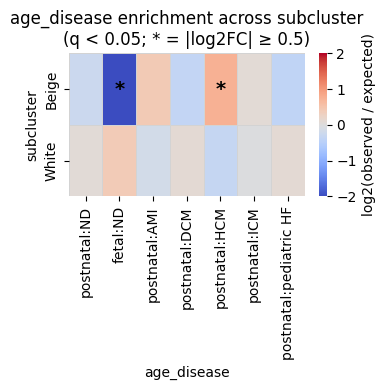

In [39]:
test_df, enrich_df, plot = funcs.chi_square_per_subcluster(
    metadata=disease_filtered_metadata,
    cluster_label="subcluster",
    study_col="age_disease",
    metadata_order = ['postnatal:ND', 'fetal:ND', 'postnatal:AMI', 'postnatal:DCM', 
                      'postnatal:HCM', 'postnatal:ICM', 'postnatal:pediatric HF'],
    min_cells=50, figsize_tuple = (4,4)
)

plot.savefig(plots_dir + cell_type + "_subcluster_age_disease.pdf")

/mnt/data1/william/human_heart_project/Final_manuscript_analysis/RNA/aggregated_analysis/v4_subclustering_analysis/examine_covariates/perform_annotation/subcluster_funcs.py:346: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for clust, sub in metadata.groupby(cluster_label):


<module 'matplotlib.pyplot' from '/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/matplotlib/pyplot.py'>


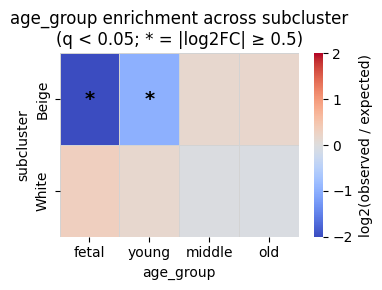

In [42]:
test_df, enrich_df, plot = funcs.chi_square_per_subcluster(
    metadata=ND_adata_metadata,
    cluster_label="subcluster",
    metadata_order = ["fetal", "young", "middle", "old"],
    study_col="age_group",
    min_cells=50, figsize_tuple = (4,3)
)

plot.savefig(plots_dir + cell_type + "_subcluster_aging.pdf")

### Save metadata

In [43]:
adata.obs.to_csv(post_subclustering_dir + cell_type + "_annotation.csv")